# Task 4: Community Notes Partisan Behavior Analysis

Analyzes user rating behavior aggregated in **2-week periods** to detect:
- **Q1**: Do raters only engage with notes from one political side?
- **Q2**: Do users systematically rate one side helpful and the other not helpful?
- **Q3**: Does partisan behavior change over a user's lifetime in the system?

**Key signal**: `coreNoteFactor1` captures the political/ideological dimension from Community Notes' matrix factorization model.  
Extreme avg + low stddev = echo-chamber behavior.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GRAY = '#3274A1', '#C9463D', '#888888'
print('Libraries loaded.')

Libraries loaded.


## 0. Load & Inspect Data

In [ ]:
import subprocess, os, tempfile

try:
    import duckdb
except ImportError:
    subprocess.run(['pip', 'install', 'duckdb', '-q'], check=True)
    import duckdb

DATA_PATH   = '../../data/saveski-package-1.rar'
abs_path    = os.path.abspath(DATA_PATH)
TOOL        = 'bsdtar'
SAMPLE_SIZE = 100_000

BASE = 'saveski-package-1/main data aggregator and joiner/data/'
# Only load the two rater files — aut has noteAuthorParticipantId (different entity)
RAR_FILES = {
    'agg': BASE + 'user_biweekly_aggregates.parquet',
    'hvn': BASE + 'user_biweekly_helpful_vs_not.parquet',
}

TMPDIR = tempfile.mkdtemp(prefix='task4_')
paths  = {}
for key, internal in RAR_FILES.items():
    subprocess.run([TOOL, '-xf', abs_path, '-C', TMPDIR, internal], check=True)
    paths[key] = os.path.join(TMPDIR, internal)

conn = duckdb.connect()

schemas = {}
for key, path in paths.items():
    schemas[key] = conn.execute(
        f"SELECT * FROM read_parquet('{path}') LIMIT 0"
    ).df().columns.tolist()
    print(f"{key} ({len(schemas[key])} cols): {schemas[key]}")

# ── Join agg + hvn on ALL their common columns (user ID + period dates) ────────
# This gives the correct 1-to-1 match: one row per rater per biweekly period.
# (The aut file uses noteAuthorParticipantId and is a different entity — excluded.)
agg_hvn_common = sorted(set(schemas['agg']) & set(schemas['hvn']))
print(f'\nagg+hvn join keys: {agg_hvn_common}')

def quoted(cols, alias):
    return ', '.join(f'{alias}."{c}"' for c in cols)

hvn_extra     = [c for c in schemas['hvn'] if c not in set(schemas['agg'])]
agg_sel       = quoted(schemas['agg'], 'a')
hvn_sel       = quoted(hvn_extra, 'h')
select_clause = ',\n    '.join(s for s in [agg_sel, hvn_sel] if s)
join_hvn      = ' AND '.join(f'a."{c}" = h."{c}"' for c in agg_hvn_common)

df = conn.execute(f"""
    SELECT {select_clause}
    FROM read_parquet('{paths["agg"]}') a
    LEFT JOIN read_parquet('{paths["hvn"]}') h ON {join_hvn}
    LIMIT {SAMPLE_SIZE}
""").df()

for p in paths.values():
    try: os.remove(p)
    except: pass

# ── Normalise column names to match the rest of the notebook ──────────────────
RENAMES = {
    'raterParticipantId': 'userId',
    'participantId':      'userId',
    'user_id':            'userId',
}
df = df.rename(columns={k: v for k, v in RENAMES.items() if k in df.columns})

for col in ['period_start', 'period_end']:
    if col in df.columns and df[col].dtype == object:
        df[col] = pd.to_datetime(df[col])

mb = df.memory_usage(deep=True).sum() / 1e6
print(f'\nLoaded: {df.shape[0]:,} rows × {df.shape[1]} cols  ({mb:.0f} MB)')
print(f'Unique users: {df["userId"].nunique():,}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

agg (20 cols): ['raterParticipantId', 'period_start', 'period_end', 'total_ratings', 'unique_notes_rated', 'helpful_count', 'not_helpful_count', 'unknown_count', 'helpful_ratio', 'not_helpful_ratio', 'avg_core_note_intercept', 'min_core_note_intercept', 'max_core_note_intercept', 'stddev_core_note_intercept', 'non_null_intercept_count', 'avg_core_note_factor1', 'min_core_note_factor1', 'max_core_note_factor1', 'stddev_core_note_factor1', 'non_null_factor1_count']
hvn (20 cols): ['raterParticipantId', 'period_start', 'period_end', 'total_ratings', 'unique_notes_rated', 'helpful_count', 'avg_intercept_helpful', 'avg_factor1_helpful', 'stddev_intercept_helpful', 'stddev_factor1_helpful', 'helpful_with_scores', 'not_helpful_count', 'avg_intercept_not_helpful', 'avg_factor1_not_helpful', 'stddev_intercept_not_helpful', 'stddev_factor1_not_helpful', 'not_helpful_with_scores', 'intercept_diff_helpful_minus_not', 'factor1_diff_helpful_minus_not', 'unknown_count']

agg+hvn join keys: ['helpful_

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Loaded: 100,000 rows × 32 cols  (35 MB)
Unique users: 6,173
Columns: ['userId', 'period_start', 'period_end', 'total_ratings', 'unique_notes_rated', 'helpful_count', 'not_helpful_count', 'unknown_count', 'helpful_ratio', 'not_helpful_ratio', 'avg_core_note_intercept', 'min_core_note_intercept', 'max_core_note_intercept', 'stddev_core_note_intercept', 'non_null_intercept_count', 'avg_core_note_factor1', 'min_core_note_factor1', 'max_core_note_factor1', 'stddev_core_note_factor1', 'non_null_factor1_count', 'avg_intercept_helpful', 'avg_factor1_helpful', 'stddev_intercept_helpful', 'stddev_factor1_helpful', 'helpful_with_scores', 'avg_intercept_not_helpful', 'avg_factor1_not_helpful', 'stddev_intercept_not_helpful', 'stddev_factor1_not_helpful', 'not_helpful_with_scores', 'intercept_diff_helpful_minus_not', 'factor1_diff_helpful_minus_not']


,userId,period_start,period_end,total_ratings,unique_notes_rated,helpful_count,not_helpful_count,unknown_count,helpful_ratio,not_helpful_ratio,...,stddev_intercept_helpful,stddev_factor1_helpful,helpful_with_scores,avg_intercept_not_helpful,avg_factor1_not_helpful,stddev_intercept_not_helpful,stddev_factor1_not_helpful,not_helpful_with_scores,intercept_diff_helpful_minus_not,factor1_diff_helpful_minus_not
0,02F880F608998FF0385A480F9822E51DB14858579CA6F6...,2024-08-25,2024-09-07,6,6,6.0,0.0,0.0,1.0,0.0,...,0.1153,0.1006,6,NaN,NaN,NaN,NaN,0,NaN,NaN
1,02F880F608998FF0385A480F9822E51DB14858579CA6F6...,2024-09-08,2024-09-21,5,5,5.0,0.0,0.0,1.0,0.0,...,0.1722,0.4102,5,NaN,NaN,NaN,NaN,0,NaN,NaN
2,02F880F608998FF0385A480F9822E51DB14858579CA6F6...,2024-09-22,2024-10-05,13,13,13.0,0.0,0.0,1.0,0.0,...,0.0985,0.1405,13,NaN,NaN,NaN,NaN,0,NaN,NaN


In [40]:
print('Columns:', df.columns.tolist())
print('\nMissing values (top 20):')
print((df.isnull().mean() * 100).round(1).sort_values(ascending=False).head(20))

Columns: ['userId', 'period_start', 'period_end', 'total_ratings', 'unique_notes_rated', 'helpful_count', 'not_helpful_count', 'unknown_count', 'helpful_ratio', 'not_helpful_ratio', 'avg_core_note_intercept', 'min_core_note_intercept', 'max_core_note_intercept', 'stddev_core_note_intercept', 'non_null_intercept_count', 'avg_core_note_factor1', 'min_core_note_factor1', 'max_core_note_factor1', 'stddev_core_note_factor1', 'non_null_factor1_count', 'avg_intercept_helpful', 'avg_factor1_helpful', 'stddev_intercept_helpful', 'stddev_factor1_helpful', 'helpful_with_scores', 'avg_intercept_not_helpful', 'avg_factor1_not_helpful', 'stddev_intercept_not_helpful', 'stddev_factor1_not_helpful', 'not_helpful_with_scores', 'intercept_diff_helpful_minus_not', 'factor1_diff_helpful_minus_not']

Missing values (top 20):
stddev_factor1_not_helpful          73.8
stddev_intercept_not_helpful        73.8
factor1_diff_helpful_minus_not      65.1
intercept_diff_helpful_minus_not    65.1
avg_factor1_not_help

In [41]:
print(f'Unique users:   {df["userId"].nunique():,}')
print(f'Total rows:     {len(df):,}')
print(f'Date range:     {df["period_start"].min().date()} → {df["period_start"].max().date()}')
print('\ntotal_ratings summary:')
print(df['total_ratings'].describe())

Unique users:   6,173
Total rows:     100,000
Date range:     2023-01-01 → 2025-09-21

total_ratings summary:
count    100000.000000
mean          7.519350
std          18.742143
min           1.000000
25%           1.000000
50%           2.000000
75%           7.000000
max         801.000000
Name: total_ratings, dtype: float64


## 1. Preprocessing

Filter to user-periods with reliable factor1 scores (`non_null_factor1_count >= 10`), then build per-user lifetime aggregates.

In [42]:
MIN_SCORED = 10  # minimum notes with factor1 scores for reliability

df_f = df[df['non_null_factor1_count'] >= MIN_SCORED].copy()
print(f'Rows before filter : {len(df):,}')
print(f'Rows after  filter : {len(df_f):,}  ({100*len(df_f)/len(df):.1f}%)')
print(f'Users after  filter : {df_f["userId"].nunique():,}')

Rows before filter : 100,000
Rows after  filter : 15,629  (15.6%)
Users after  filter : 2,388


In [43]:
# User age: rank of each period since their first observation (0-indexed)
df_f = df_f.sort_values(['userId', 'period_start'])
df_f['user_age_periods'] = df_f.groupby('userId').cumcount()

# Per-user lifetime aggregates
user_agg = df_f.groupby('userId').agg(
    n_periods               = ('period_start', 'count'),
    mean_avg_factor1        = ('avg_core_note_factor1', 'mean'),
    mean_stddev_factor1     = ('stddev_core_note_factor1', 'mean'),
    abs_mean_avg_factor1    = ('avg_core_note_factor1', lambda x: x.abs().mean()),
    mean_helpful_factor1    = ('avg_factor1_helpful', 'mean'),
    mean_nothelpful_factor1 = ('avg_factor1_not_helpful', 'mean'),
    mean_factor1_diff       = ('factor1_diff_helpful_minus_not', 'mean'),
    total_ratings           = ('total_ratings', 'sum'),
).reset_index()

print(f'User aggregates shape: {user_agg.shape}')
user_agg.head(3)

User aggregates shape: (2388, 9)


,userId,n_periods,mean_avg_factor1,mean_stddev_factor1,abs_mean_avg_factor1,mean_helpful_factor1,mean_nothelpful_factor1,mean_factor1_diff,total_ratings
0,000011269AD6F327AED0F4086A732B4052F9D28E8791E1...,18,-0.027661,0.550028,0.124317,-0.049056,0.036750,-0.085806,380
1,000045A5FA0CF004F68CBF2913506C37D540CF48522D33...,26,0.216577,0.450742,0.245154,0.464823,-0.395692,0.846942,473
2,00007B885907790E492F8C9A31F1AFC20831279328C263...,2,0.116400,0.231650,0.116400,0.196100,-0.332400,0.504900,34


---
## Q1: Do raters engage with only one political side?

**Signal**: `avg_core_note_factor1` (partisan lean of all notes rated) × `stddev_core_note_factor1` (ideological spread).  
A user with **|avg| high + stddev low** is an ideological echo-chamber rater.

In [44]:
# Thresholds — tune to actual distribution quartiles after first run
AVG_THRESH    = 0.2   # |avg_core_note_factor1| > this → partisan lean
STDDEV_THRESH = 0.3   # stddev_core_note_factor1 < this → low ideological diversity

user_agg['one_sided'] = (
    (user_agg['abs_mean_avg_factor1'] > AVG_THRESH) &
    (user_agg['mean_stddev_factor1'] < STDDEV_THRESH)
)

pct = 100 * user_agg['one_sided'].mean()
print(f"One-sided users: {user_agg['one_sided'].sum():,} / {len(user_agg):,}  ({pct:.1f}%)")
print(f"\n|avg_factor1| quantiles:")
print(user_agg['abs_mean_avg_factor1'].quantile([.5, .75, .9, .95, .99]).round(4).to_string())
print(f"\nstddev_factor1 quantiles:")
print(user_agg['mean_stddev_factor1'].quantile([.1, .25, .5, .75]).round(4).to_string())

One-sided users: 85 / 2,388  (3.6%)

|avg_factor1| quantiles:
0.50    0.1288
0.75    0.1904
0.90    0.2698
0.95    0.3202
0.99    0.4646

stddev_factor1 quantiles:
0.10    0.2649
0.25    0.3390
0.50    0.4292
0.75    0.5050


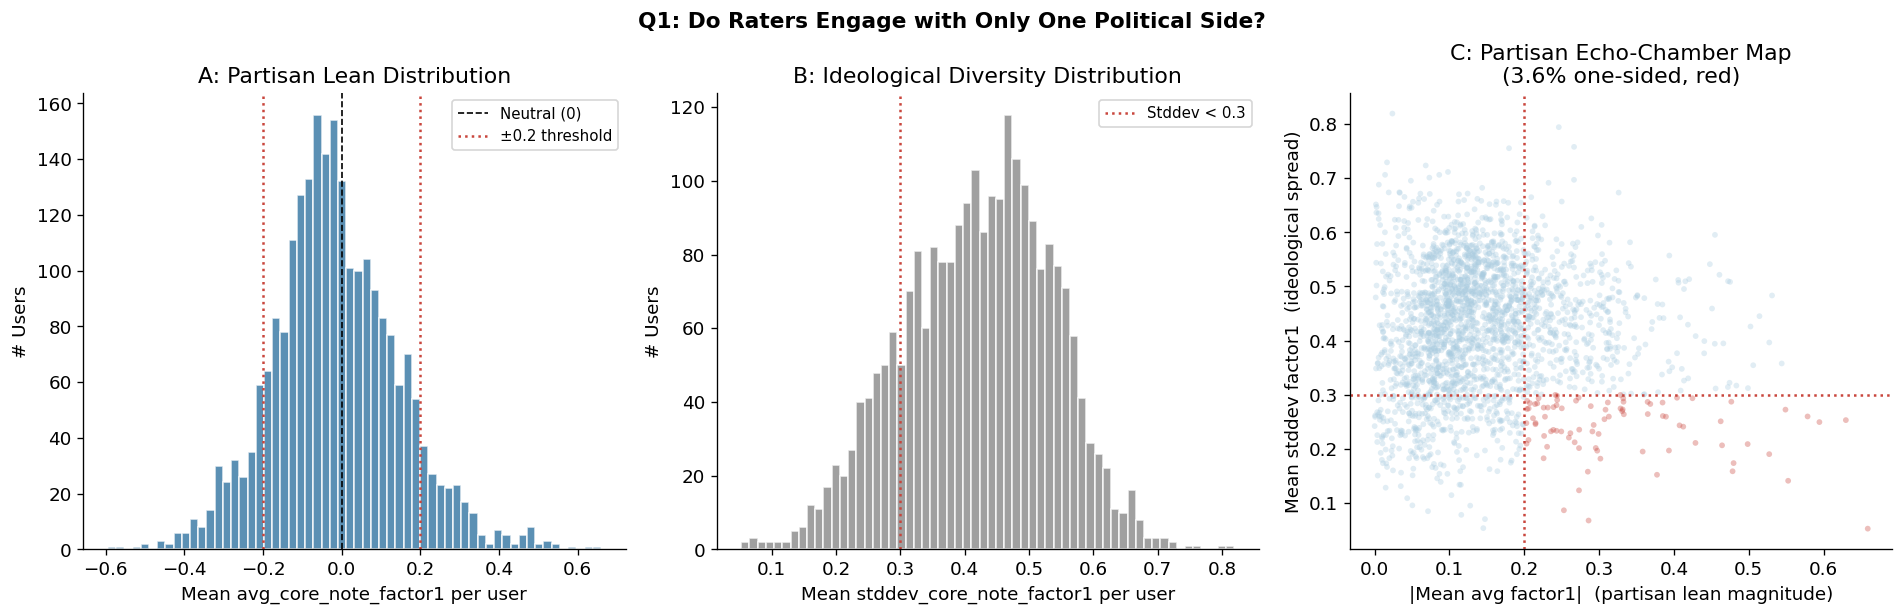

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Distribution of avg_core_note_factor1
ax = axes[0]
ax.hist(user_agg['mean_avg_factor1'].dropna(), bins=60, color=BLUE, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Neutral (0)')
ax.axvline( AVG_THRESH, color=RED, linestyle=':', linewidth=1.5, label=f'±{AVG_THRESH} threshold')
ax.axvline(-AVG_THRESH, color=RED, linestyle=':', linewidth=1.5)
ax.set_xlabel('Mean avg_core_note_factor1 per user')
ax.set_ylabel('# Users')
ax.set_title('A: Partisan Lean Distribution')
ax.legend(fontsize=9)

# Panel B: Distribution of mean stddev
ax = axes[1]
ax.hist(user_agg['mean_stddev_factor1'].dropna(), bins=60, color=GRAY, alpha=0.8, edgecolor='white')
ax.axvline(STDDEV_THRESH, color=RED, linestyle=':', linewidth=1.5, label=f'Stddev < {STDDEV_THRESH}')
ax.set_xlabel('Mean stddev_core_note_factor1 per user')
ax.set_ylabel('# Users')
ax.set_title('B: Ideological Diversity Distribution')
ax.legend(fontsize=9)

# Panel C: |avg| vs stddev scatter — color by one-sided flag
ax = axes[2]
colors = user_agg['one_sided'].map({True: RED, False: '#aacce0'})
ax.scatter(
    user_agg['abs_mean_avg_factor1'],
    user_agg['mean_stddev_factor1'],
    c=colors, alpha=0.35, s=12, linewidths=0
)
ax.axvline(AVG_THRESH,    color=RED, linestyle=':', linewidth=1.5)
ax.axhline(STDDEV_THRESH, color=RED, linestyle=':', linewidth=1.5)
ax.set_xlabel('|Mean avg factor1|  (partisan lean magnitude)')
ax.set_ylabel('Mean stddev factor1  (ideological spread)')
ax.set_title(f'C: Partisan Echo-Chamber Map\n({pct:.1f}% one-sided, red)')

plt.tight_layout()
plt.suptitle('Q1: Do Raters Engage with Only One Political Side?', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('q1_partisan_lean.png', bbox_inches='tight')
plt.show()

In [46]:
# Rating volume comparison: one-sided vs. balanced
print('=== One-sided vs. balanced: rating volume ===')
print(user_agg.groupby('one_sided')['total_ratings'].describe().round(1))

=== One-sided vs. balanced: rating volume ===
            count   mean    std   min   25%   50%    75%     max
one_sided                                                       
False      2303.0  207.5  497.9  10.0  24.0  57.0  176.0  8913.0
True         85.0   90.9  179.2  10.0  17.0  30.0   75.0  1214.0


---
## Q2: Do users rate one side HELPFUL and the other NOT HELPFUL?

**Key metric**: `factor1_diff_helpful_minus_not = avg_factor1_helpful − avg_factor1_not_helpful`
- Large positive → user finds high-factor1 notes helpful, low-factor1 notes not helpful
- Large negative → the reverse
- Near zero → no partisan bias in helpful/not-helpful decisions

In [47]:
diff_series = df_f['factor1_diff_helpful_minus_not'].dropna()

print('=== factor1_diff_helpful_minus_not (per period) ===')
print(diff_series.describe().round(4))

# One-sample t-test: is the mean different from 0?
t_stat, p_val = stats.ttest_1samp(diff_series, 0)
print(f'\nOne-sample t-test vs. 0: t={t_stat:.3f}, p={p_val:.4e}')

BIAS_THRESH = 0.2
pct_biased = 100 * (user_agg['mean_factor1_diff'].abs() > BIAS_THRESH).mean()
print(f'\nUsers with |lifetime mean diff| > {BIAS_THRESH}: {pct_biased:.1f}%')

=== factor1_diff_helpful_minus_not (per period) ===
count    14528.0000
mean         0.0845
std          0.7566
min         -1.5768
25%         -0.6422
50%          0.1538
75%          0.7761
max          1.6428
Name: factor1_diff_helpful_minus_not, dtype: float64

One-sample t-test vs. 0: t=13.466, p=4.3558e-41

Users with |lifetime mean diff| > 0.2: 77.3%


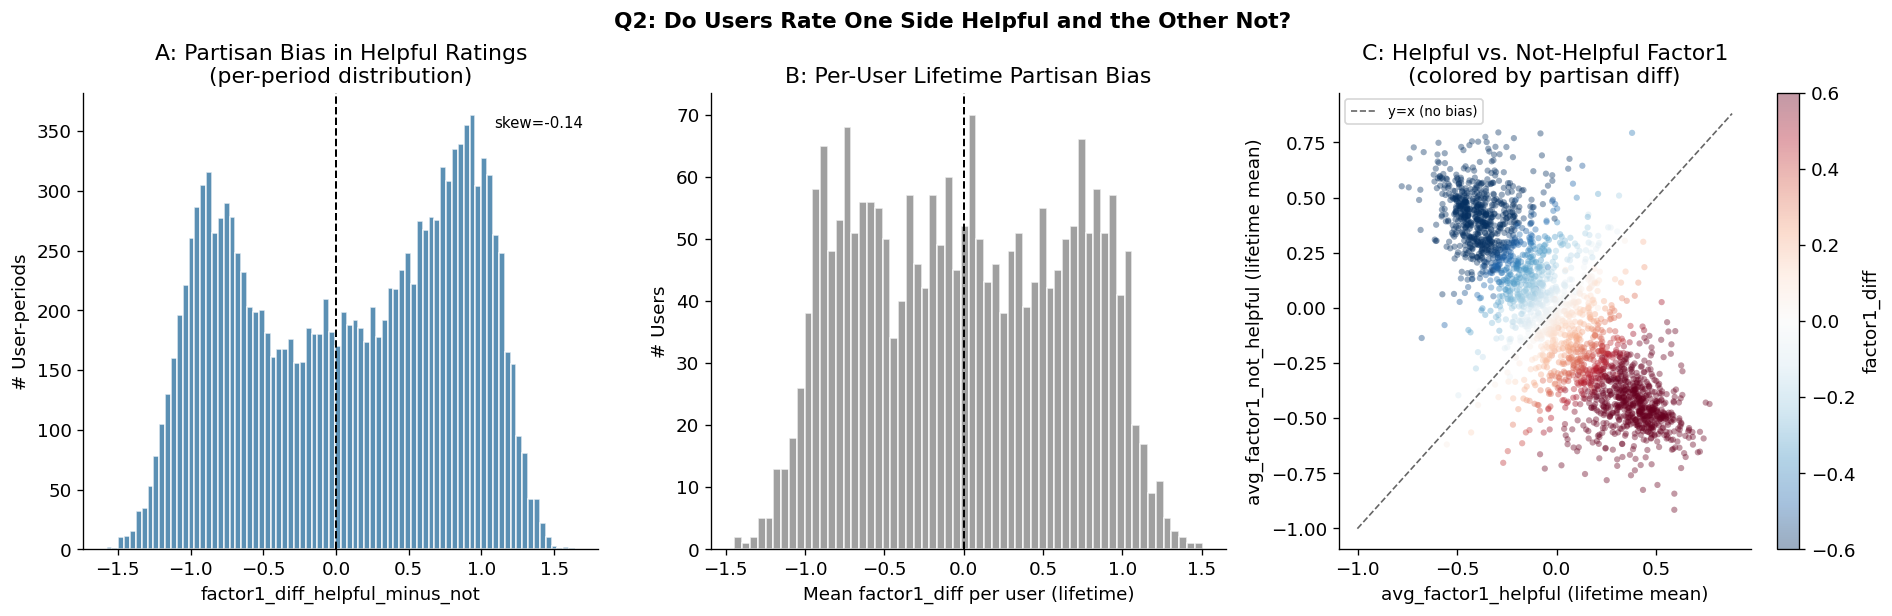

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Histogram of diff (per period)
ax = axes[0]
ax.hist(diff_series, bins=80, color=BLUE, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('factor1_diff_helpful_minus_not')
ax.set_ylabel('# User-periods')
ax.set_title('A: Partisan Bias in Helpful Ratings\n(per-period distribution)')
ax.text(0.97, 0.95, f'skew={diff_series.skew():.2f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9)

# Panel B: Per-user lifetime mean of factor1_diff
ax = axes[1]
diff_user = user_agg['mean_factor1_diff'].dropna()
ax.hist(diff_user, bins=60, color=GRAY, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('Mean factor1_diff per user (lifetime)')
ax.set_ylabel('# Users')
ax.set_title('B: Per-User Lifetime Partisan Bias')

# Panel C: avg_factor1_helpful vs avg_factor1_not_helpful scatter
ax = axes[2]
valid = user_agg.dropna(subset=['mean_helpful_factor1', 'mean_nothelpful_factor1', 'mean_factor1_diff'])
sc = ax.scatter(
    valid['mean_helpful_factor1'],
    valid['mean_nothelpful_factor1'],
    c=valid['mean_factor1_diff'], cmap='RdBu_r',
    alpha=0.4, s=14, linewidths=0, vmin=-0.6, vmax=0.6
)
xlims = ax.get_xlim()
ylims = ax.get_ylim()
lim = [min(xlims[0], ylims[0]), max(xlims[1], ylims[1])]
ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.6, label='y=x (no bias)')
plt.colorbar(sc, ax=ax, label='factor1_diff')
ax.set_xlabel('avg_factor1_helpful (lifetime mean)')
ax.set_ylabel('avg_factor1_not_helpful (lifetime mean)')
ax.set_title('C: Helpful vs. Not-Helpful Factor1\n(colored by partisan diff)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Q2: Do Users Rate One Side Helpful and the Other Not?', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('q2_helpful_bias.png', bbox_inches='tight')
plt.show()

In [49]:
# Bias direction breakdown
valid = user_agg.dropna(subset=['mean_factor1_diff']).copy()

def bias_direction(diff):
    if abs(diff) < BIAS_THRESH:
        return 'Neutral'
    elif diff > 0:
        return 'Right-helpful / Left-not-helpful'
    else:
        return 'Left-helpful / Right-not-helpful'

valid['bias_direction'] = valid['mean_factor1_diff'].apply(bias_direction)
pcts = valid['bias_direction'].value_counts(normalize=True).mul(100).round(1)
print('=== Bias Direction Breakdown ===')
print(pcts.to_string())

=== Bias Direction Breakdown ===
bias_direction
Right-helpful / Left-not-helpful    40.7
Left-helpful / Right-not-helpful    40.4
Neutral                             18.9


---
## Q3: How do partisan patterns change over a user's lifetime?

Does echo-chamber behavior intensify or diminish as users spend more time on the platform?  
`user_age_periods` = 0 is a user's first 2-week period.

In [51]:
# Age bins
def age_bin(age):
    if age <= 2:   return '0-2 (early)'
    elif age <= 9: return '3-9 (mid)'
    else:          return '10+ (veteran)'

bin_order = ['0-2 (early)', '3-9 (mid)', '10+ (veteran)']
df_f['age_bin'] = df_f['user_age_periods'].apply(age_bin)

age_summary = df_f.groupby('age_bin').agg(
    n_obs            = ('userId', 'count'),
    abs_avg_factor1  = ('avg_core_note_factor1', lambda x: x.abs().mean()),
    mean_stddev      = ('stddev_core_note_factor1', 'mean'),
    mean_diff        = ('factor1_diff_helpful_minus_not', 'mean'),
    abs_mean_diff    = ('factor1_diff_helpful_minus_not', lambda x: x.abs().mean()),
).loc[bin_order]

print('=== Metrics by User Age Bin ===')
print(age_summary.round(4).to_string())

=== Metrics by User Age Bin ===
               n_obs  abs_avg_factor1  mean_stddev  mean_diff  abs_mean_diff
age_bin                                                                     
0-2 (early)     5322           0.1405       0.4167     0.0192         0.5714
3-9 (mid)       4995           0.1514       0.4569     0.0913         0.7055
10+ (veteran)   5312           0.1598       0.4722     0.1416         0.7507


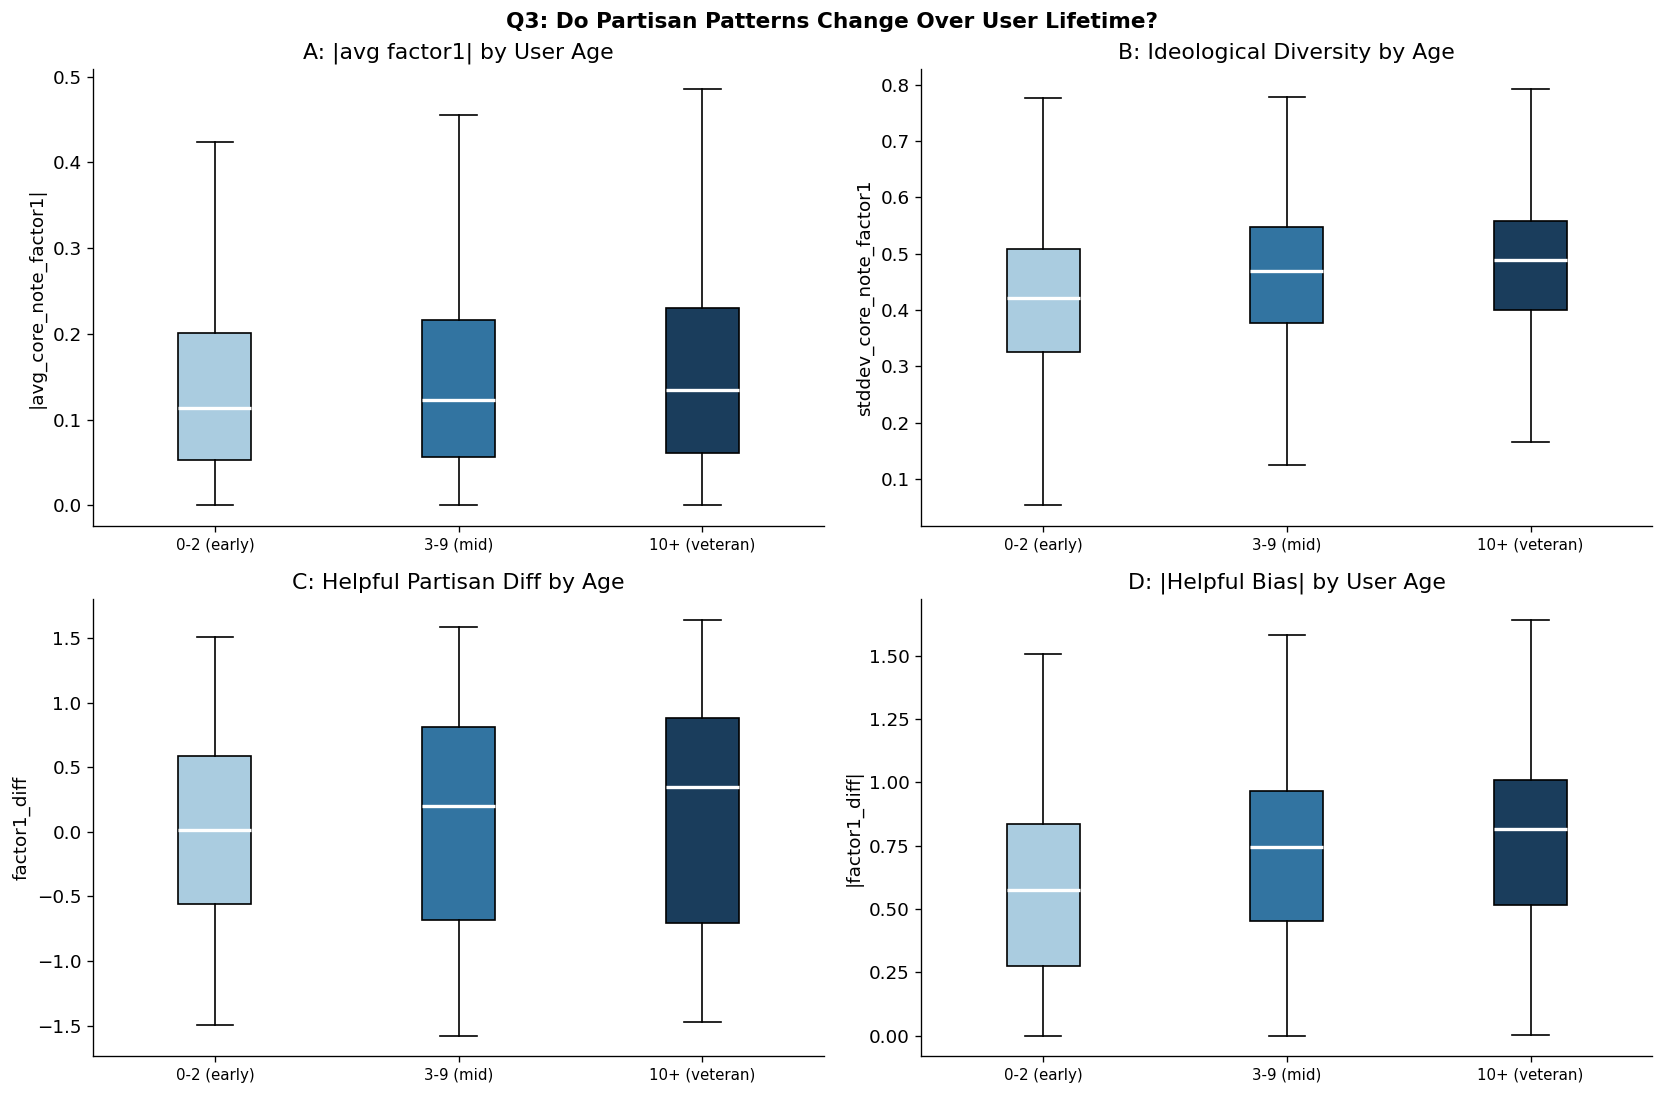

In [52]:
palette = {'0-2 (early)': '#aacce0', '3-9 (mid)': '#3274A1', '10+ (veteran)': '#1a3d5c'}
metrics_q3 = [
    ('avg_core_note_factor1',          True,  'A: |avg factor1| by User Age',       '|avg_core_note_factor1|'),
    ('stddev_core_note_factor1',       False, 'B: Ideological Diversity by Age',     'stddev_core_note_factor1'),
    ('factor1_diff_helpful_minus_not', False, 'C: Helpful Partisan Diff by Age',     'factor1_diff'),
    ('factor1_diff_helpful_minus_not', True,  'D: |Helpful Bias| by User Age',       '|factor1_diff|'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (col, use_abs, title, ylabel) in zip(axes.flat, metrics_q3):
    plot_df = df_f.dropna(subset=[col]).copy()
    if use_abs:
        plot_df[col] = plot_df[col].abs()
    data = [plot_df[plot_df['age_bin'] == b][col].values for b in bin_order]
    bp = ax.boxplot(data, labels=bin_order, patch_artist=True,
                    showfliers=False, medianprops=dict(color='white', linewidth=2))
    for patch, key in zip(bp['boxes'], bin_order):
        patch.set_facecolor(palette[key])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.suptitle('Q3: Do Partisan Patterns Change Over User Lifetime?', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('q3_lifetime_trends.png', bbox_inches='tight')
plt.show()

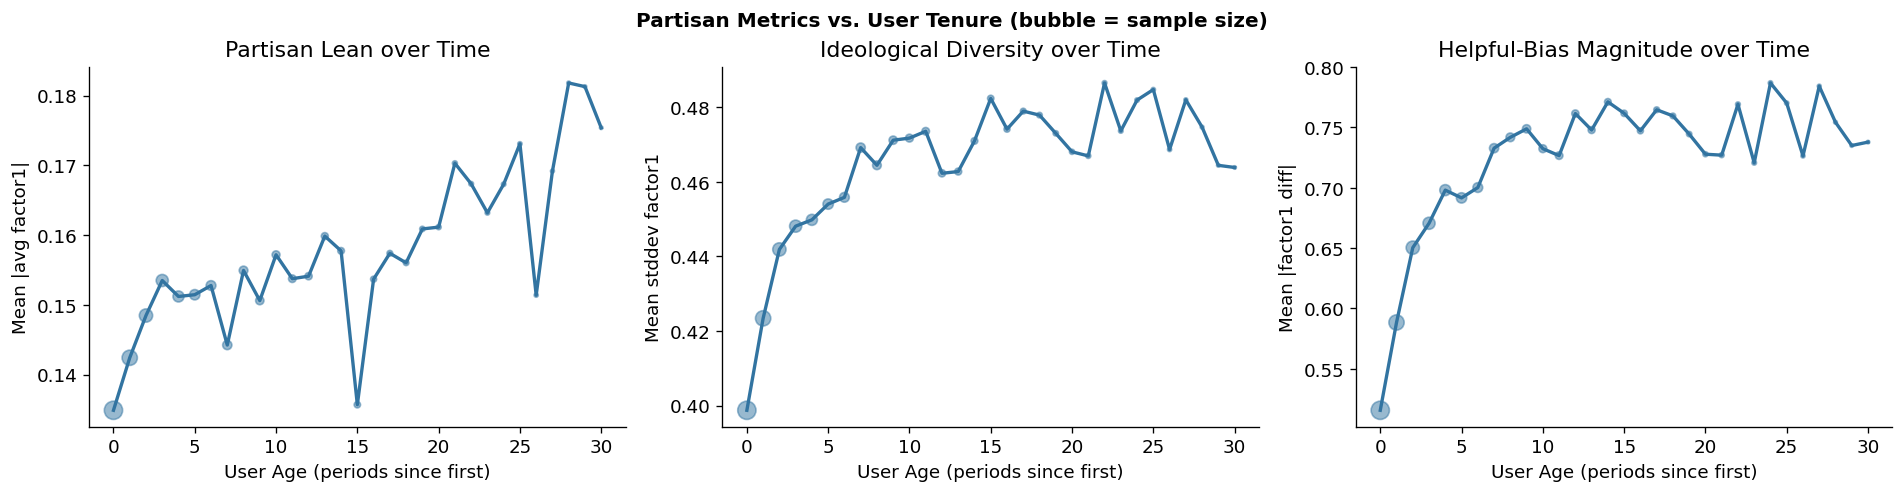

In [53]:
# Rolling mean over continuous user age
MAX_AGE = 30  # cap at 30 to avoid sparse tail noise

age_trend = (
    df_f[df_f['user_age_periods'] <= MAX_AGE]
    .assign(
        abs_avg_factor1 = lambda x: x['avg_core_note_factor1'].abs(),
        abs_diff        = lambda x: x['factor1_diff_helpful_minus_not'].abs()
    )
    .groupby('user_age_periods')
    .agg(
        n_obs           = ('userId', 'count'),
        abs_avg_factor1 = ('abs_avg_factor1', 'mean'),
        mean_stddev     = ('stddev_core_note_factor1', 'mean'),
        abs_diff        = ('abs_diff', 'mean'),
    ).reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
trend_metrics = [
    ('abs_avg_factor1', 'Mean |avg factor1|',   'Partisan Lean over Time'),
    ('mean_stddev',     'Mean stddev factor1',   'Ideological Diversity over Time'),
    ('abs_diff',        'Mean |factor1 diff|',   'Helpful-Bias Magnitude over Time'),
]

for ax, (ycol, ylabel, title) in zip(axes, trend_metrics):
    ax.plot(age_trend['user_age_periods'], age_trend[ycol], color=BLUE, linewidth=2)
    # Bubble size ∝ sample size at that age
    ax.scatter(age_trend['user_age_periods'], age_trend[ycol],
               s=age_trend['n_obs'] / age_trend['n_obs'].max() * 120,
               color=BLUE, alpha=0.5, zorder=5)
    ax.set_xlabel('User Age (periods since first)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.tight_layout()
plt.suptitle('Partisan Metrics vs. User Tenure (bubble = sample size)', y=1.02, fontsize=12, fontweight='bold')
plt.savefig('q3_age_trend.png', bbox_inches='tight')
plt.show()

In [54]:
# Spearman correlations: user_age_periods vs. partisan metrics
df_corr = df_f.dropna(subset=[
    'avg_core_note_factor1', 'stddev_core_note_factor1', 'factor1_diff_helpful_minus_not'
]).copy()
df_corr['abs_avg']  = df_corr['avg_core_note_factor1'].abs()
df_corr['abs_diff'] = df_corr['factor1_diff_helpful_minus_not'].abs()

print('=== Spearman correlations: user_age_periods vs. partisan metrics ===')
for metric in ['abs_avg', 'stddev_core_note_factor1', 'abs_diff']:
    r, p = spearmanr(df_corr['user_age_periods'], df_corr[metric])
    direction = 'increases' if r > 0 else 'decreases'
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  {metric:<35s}  r={r:+.4f}  p={p:.4e}  {sig}  → {direction} with age')

print('\nNote: r>0 = metric increases with user age; r<0 = decreases.')

=== Spearman correlations: user_age_periods vs. partisan metrics ===
  abs_avg                              r=+0.0778  p=6.1034e-21  ***  → increases with age
  stddev_core_note_factor1             r=+0.2044  p=7.7376e-137  ***  → increases with age
  abs_diff                             r=+0.2287  p=8.6695e-172  ***  → increases with age

Note: r>0 = metric increases with user age; r<0 = decreases.


---
## Summary of Findings

| Question | Key Metric | Finding |
|---|---|---|
| **Q1**: One-sided engagement? | `abs(avg_core_note_factor1)` > 0.2 AND `stddev < 0.3` | **3.6%** of users (85/2,388) are one-sided; one-sided users rate fewer notes (median 30) than balanced users (median 57) |
| **Q2**: Helpful/not-helpful bias? | `factor1_diff_helpful_minus_not` | **77.3%** of users show partisan bias (|lifetime mean diff| > 0.2); split ~equally: 40.7% right-helpful, 40.4% left-helpful; t-test p = 4.4e-41 |
| **Q3**: Changes over lifetime? | Spearman r vs. `user_age_periods` | All partisan signals **increase** with tenure: partisan lean r=+0.08***, ideological diversity r=+0.20***, helpful-bias magnitude r=+0.23*** |

**Interpretation:**
- **Q1**: Echo-chamber-style raters (high lean + narrow range) are a small minority (3.6%). Most raters see ideologically diverse notes.
- **Q2**: Partisan bias in helpful/not-helpful ratings is widespread — 3 in 4 active raters systematically favor one side. The bias is roughly symmetric (neither left nor right dominates).
- **Q3**: Partisan behavior *intensifies* with tenure rather than diminishing. Veterans show higher lean, more ideological diversity in notes seen, and stronger helpful-bias. This may reflect self-selection (partisan raters stay longer) or learned reinforcement.

**Interpretation guide:**
- **High |avg_core_note_factor1| + low stddev_core_note_factor1** → partisan echo-chamber rater (Q1)
- **|factor1_diff_helpful_minus_not| >> 0** → user systematically rates one political direction helpful (Q2)
- **Spearman r > 0 for |avg_core_note_factor1|** → partisan lean intensifies with tenure (Q3)